# SilverFlow EDA

**資料來源**
- 合成健康資料：100 位虛擬使用者 × 90 天（senior / midage / healthy 三族群）
- 長照機構資料：衛福部長照機構清單（合成，262 筆，22 縣市）
- 人口資料：內政部統計處 2024 年各縣市 65 歲以上人口

**分析目標**
1. 各縣市長照床位缺口排名
2. 各族群週健康趨勢（HRV、睡眠）
3. 縣市長照資源密度 vs 健康指標散點圖
4. 統計檢定：65+ vs 中年族群 HRV 差異
5. 相關性分析：縣市長照資源 vs 健康指標

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats

matplotlib.rcParams['font.family'] = ['Arial Unicode MS', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted')

DB = Path('..') / 'silverflow.duckdb'
con = duckdb.connect(str(DB), read_only=True)

ltc_gap     = con.execute('SELECT * FROM gold_ltc_gap').df()
health_wkly = con.execute('SELECT * FROM gold_health_weekly').df()
cross       = con.execute('SELECT * FROM gold_ltc_health_cross').df()
health_raw  = con.execute('SELECT * FROM stg_health_records WHERE NOT is_imputed').df()

print('gold_ltc_gap:', ltc_gap.shape)
print('gold_health_weekly:', health_wkly.shape)
print('gold_ltc_health_cross:', cross.shape)

gold_ltc_gap: (22, 9)
gold_health_weekly: (1300, 9)
gold_ltc_health_cross: (40, 11)


## 1. 各縣市長照床位缺口排名

`beds_per_1000_seniors`：每千位 65+ 人口的核准床位數，越低缺口越大。

/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/3846500090.py:13: UserWarning: Glyph 26032 (\N{CJK UNIFIED IDEOGRAPH-65B0}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/3846500090.py:13: UserWarning: Glyph 31481 (\N{CJK UNIFIED IDEOGRAPH-7AF9}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/3846500090.py:13: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/3846500090.py:13: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/3846500090.py:13: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/i

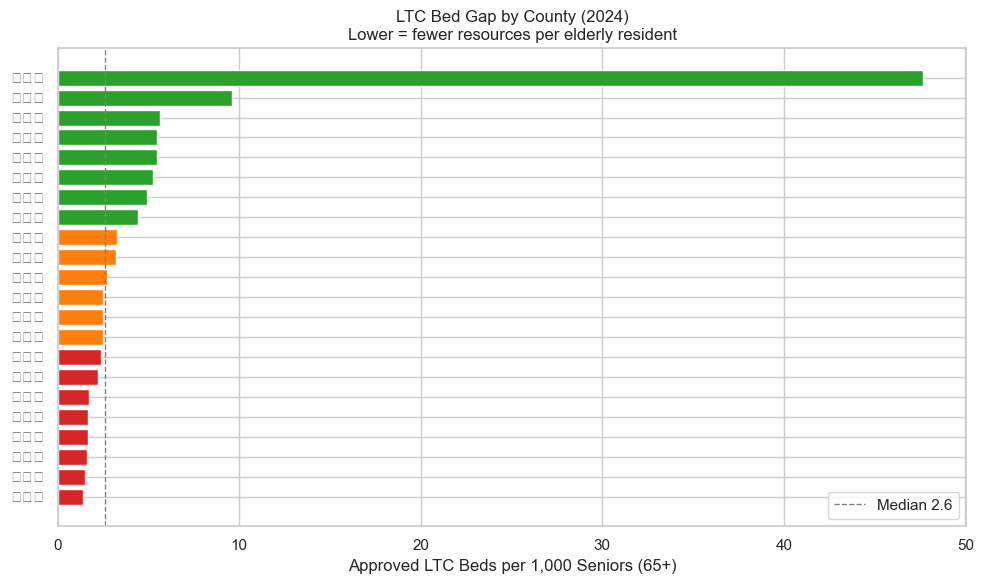

Bottom 5 counties (largest gap):
county  beds_per_1000_seniors  senior_population_65plus
   新竹市                   1.41                     70383
   屏東縣                   1.52                    165532
   彰化縣                   1.64                    238924
   臺北市                   1.67                    574458
   新北市                   1.69                    768492


In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

df = ltc_gap.sort_values('beds_per_1000_seniors')
colors = ['#d62728' if v < 2.5 else '#ff7f0e' if v < 4 else '#2ca02c'
          for v in df['beds_per_1000_seniors']]

ax.barh(df['county'], df['beds_per_1000_seniors'], color=colors)
ax.axvline(df['beds_per_1000_seniors'].median(), color='gray',
           linestyle='--', linewidth=1, label=f'Median {df["beds_per_1000_seniors"].median():.1f}')
ax.set_xlabel('Approved LTC Beds per 1,000 Seniors (65+)')
ax.set_title('LTC Bed Gap by County (2024)\nLower = fewer resources per elderly resident')
ax.legend()
plt.tight_layout()
plt.savefig('ltc_gap_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print('Bottom 5 counties (largest gap):')
print(df[['county','beds_per_1000_seniors','senior_population_65plus']].head(5).to_string(index=False))

## 2. 各族群週平均健康趨勢

觀察 senior / midage / healthy 三族群在 90 天內的 HRV 與睡眠變化。

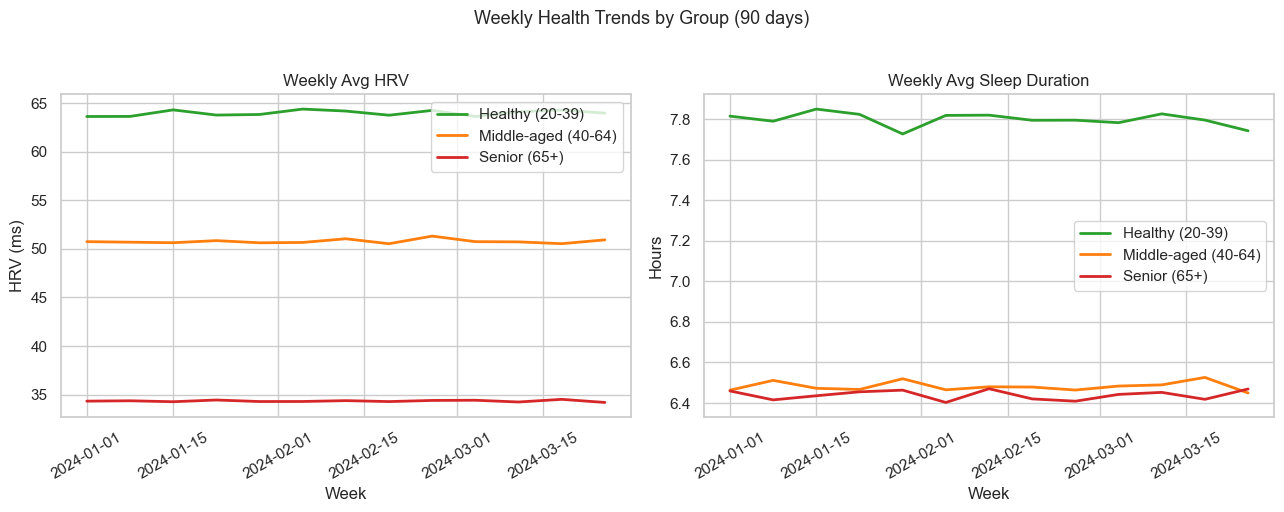

In [3]:
weekly_mean = (
    health_wkly
    .groupby(['user_group', 'week_start'])[['avg_hrv', 'avg_sleep_hrs']]
    .mean()
    .reset_index()
)
weekly_mean['week_start'] = pd.to_datetime(weekly_mean['week_start'])

group_labels = {'senior': 'Senior (65+)', 'midage': 'Middle-aged (40-64)', 'healthy': 'Healthy (20-39)'}
group_colors = {'senior': '#d62728', 'midage': '#ff7f0e', 'healthy': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for grp, df_g in weekly_mean.groupby('user_group'):
    axes[0].plot(df_g['week_start'], df_g['avg_hrv'],
                 label=group_labels[grp], color=group_colors[grp], linewidth=2)
    axes[1].plot(df_g['week_start'], df_g['avg_sleep_hrs'],
                 label=group_labels[grp], color=group_colors[grp], linewidth=2)

axes[0].set_title('Weekly Avg HRV')
axes[0].set_ylabel('HRV (ms)')
axes[0].set_xlabel('Week')
axes[0].legend()

axes[1].set_title('Weekly Avg Sleep Duration')
axes[1].set_ylabel('Hours')
axes[1].set_xlabel('Week')
axes[1].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Weekly Health Trends by Group (90 days)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('health_trend_weekly.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 跨域散點圖：縣市長照資源 vs 65+ 平均壓力

用 `gold_ltc_health_cross` 的縣市聚合資料，看資源充裕度和族群健康的關係。

/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/961426943.py:37: UserWarning: Glyph 21335 (\N{CJK UNIFIED IDEOGRAPH-5357}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/961426943.py:37: UserWarning: Glyph 25237 (\N{CJK UNIFIED IDEOGRAPH-6295}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/961426943.py:37: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/961426943.py:37: UserWarning: Glyph 22025 (\N{CJK UNIFIED IDEOGRAPH-5609}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/961426943.py:37: UserWarning: Glyph 32681 (\N{CJK UNIFIED IDEOGRAPH-7FA9}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipyker

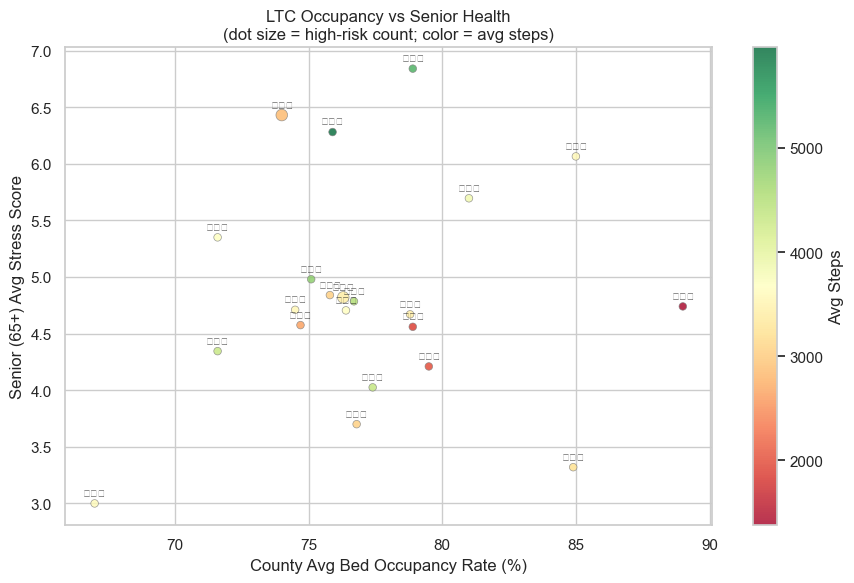

In [4]:
county_agg = (
    cross
    .groupby('county')
    .agg(
        avg_stress=('avg_stress', 'mean'),
        avg_steps=('avg_steps', 'mean'),
        beds_per_1000=('available_beds', 'first'),
        occupancy=('avg_occupancy_rate_pct', 'first'),
        high_risk_count=('is_high_risk', 'sum'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    county_agg['occupancy'],
    county_agg['avg_stress'],
    s=county_agg['high_risk_count'] * 40 + 30,
    c=county_agg['avg_steps'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='gray',
    linewidth=0.5,
)

plt.colorbar(sc, ax=ax, label='Avg Steps')

for _, row in county_agg.iterrows():
    ax.annotate(row['county'], (row['occupancy'], row['avg_stress']),
                fontsize=7.5, ha='center', va='bottom', xytext=(0, 4),
                textcoords='offset points')

ax.set_xlabel('County Avg Bed Occupancy Rate (%)')
ax.set_ylabel('Senior (65+) Avg Stress Score')
ax.set_title('LTC Occupancy vs Senior Health\n(dot size = high-risk count; color = avg steps)')
plt.tight_layout()
plt.savefig('ltc_health_cross.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 統計檢定：65+ vs 中年族群 HRV 差異

**假設**：senior 族群的 HRV 顯著低於 midage 族群。

使用 Welch's t-test（不假設等變異數）。

=== Welch t-test: Senior vs Middle-aged HRV ===
  Senior   n=3,600  mean=34.3  std=9.4
  Middle-aged  n=3,150  mean=50.8  std=8.7
  t = -74.607,  p = 0.00e+00

Conclusion: p < 0.001, highly significant.
  Seniors show significantly lower HRV than middle-aged adults,
  consistent with age-related decline in autonomic nervous system function.


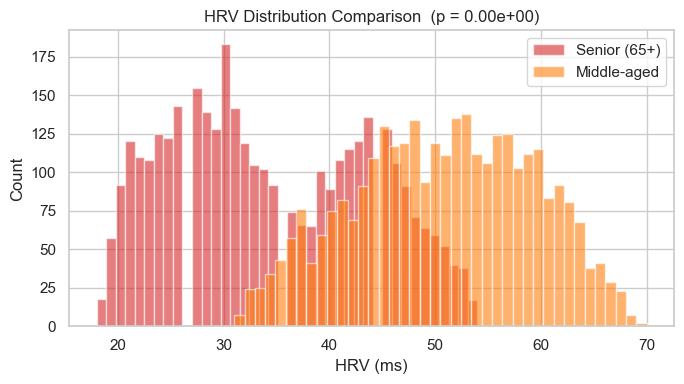

In [5]:
senior_hrv = health_raw[health_raw['user_group'] == 'senior']['hrv']
midage_hrv = health_raw[health_raw['user_group'] == 'midage']['hrv']

t_stat, p_value = stats.ttest_ind(senior_hrv, midage_hrv, equal_var=False)

print('=== Welch t-test: Senior vs Middle-aged HRV ===')
print(f'  Senior   n={len(senior_hrv):,}  mean={senior_hrv.mean():.1f}  std={senior_hrv.std():.1f}')
print(f'  Middle-aged  n={len(midage_hrv):,}  mean={midage_hrv.mean():.1f}  std={midage_hrv.std():.1f}')
print(f'  t = {t_stat:.3f},  p = {p_value:.2e}')
print()
if p_value < 0.001:
    print('Conclusion: p < 0.001, highly significant.')
    print('  Seniors show significantly lower HRV than middle-aged adults,')
    print('  consistent with age-related decline in autonomic nervous system function.')
elif p_value < 0.05:
    print('Conclusion: p < 0.05, significant difference.')
else:
    print('Conclusion: p >= 0.05, no significant difference.')

fig, ax = plt.subplots(figsize=(7, 4))
for grp, color, label in [('senior', '#d62728', 'Senior (65+)'), ('midage', '#ff7f0e', 'Middle-aged')]:
    ax.hist(health_raw[health_raw['user_group'] == grp]['hrv'],
            bins=40, alpha=0.6, color=color, label=label)
ax.set_xlabel('HRV (ms)')
ax.set_ylabel('Count')
ax.set_title(f'HRV Distribution Comparison  (p = {p_value:.2e})')
ax.legend()
plt.tight_layout()
plt.savefig('hrv_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 相關性分析：縣市長照資源 vs 健康指標

用 `gold_ltc_gap` 的 `beds_per_1000_seniors` 與 `gold_ltc_health_cross` 的縣市聚合健康指標
做 Pearson / Spearman 相關分析。

Correlation: beds_per_1000_seniors vs senior health metrics
Metric          Pearson r          p    Spearman r          p  Sig
---------------------------------------------------------------------------
Avg Stress         -0.379      0.082        -0.061      0.787  
Avg Steps          -0.012      0.958         0.034      0.879  
Avg HRV            -0.060      0.791         0.032      0.887  

Note: n=22 counties; limited statistical power.
County assignment is synthetic (user_id mod 22) — correlations are directional only.


/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/2472973662.py:46: UserWarning: Glyph 21335 (\N{CJK UNIFIED IDEOGRAPH-5357}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/2472973662.py:46: UserWarning: Glyph 25237 (\N{CJK UNIFIED IDEOGRAPH-6295}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/2472973662.py:46: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/2472973662.py:46: UserWarning: Glyph 22025 (\N{CJK UNIFIED IDEOGRAPH-5609}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/ipykernel_59035/2472973662.py:46: UserWarning: Glyph 32681 (\N{CJK UNIFIED IDEOGRAPH-7FA9}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r0/87r5sy210ln1dwcprb6v4c_40000gn/T/i

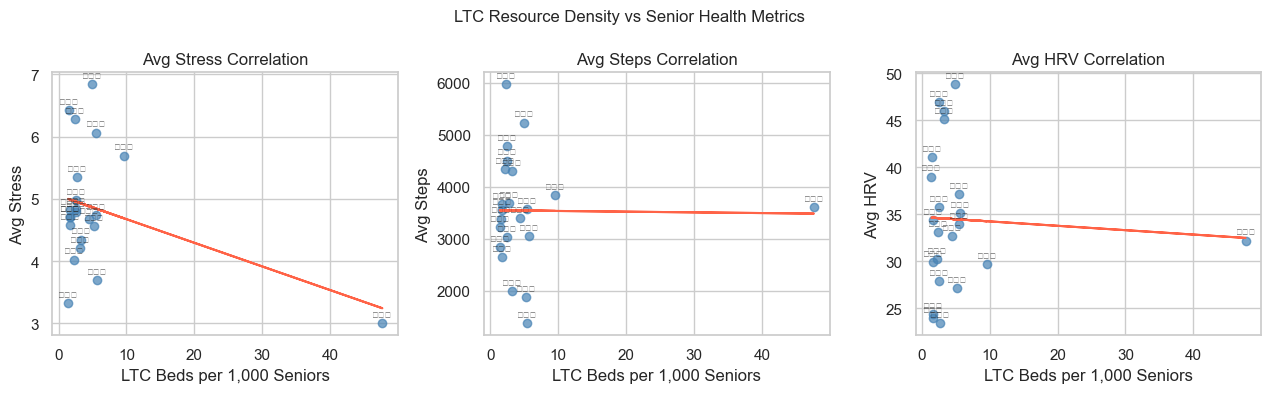

In [6]:
county_health = (
    cross
    .groupby('county')
    .agg(avg_stress=('avg_stress', 'mean'),
         avg_steps=('avg_steps', 'mean'),
         avg_hrv=('avg_hrv', 'mean'))
    .reset_index()
)
merged = county_health.merge(
    ltc_gap[['county', 'beds_per_1000_seniors', 'avg_occupancy_rate_pct']],
    on='county'
)

metrics = ['avg_stress', 'avg_steps', 'avg_hrv']
labels  = ['Avg Stress', 'Avg Steps', 'Avg HRV']
resource_col = 'beds_per_1000_seniors'

print(f'Correlation: {resource_col} vs senior health metrics')
print(f'{"Metric":<14} {"Pearson r":>10} {"p":>10}  {"Spearman r":>12} {"p":>10}  Sig')
print('-' * 75)
for col, lbl in zip(metrics, labels):
    pr, pp = stats.pearsonr(merged[resource_col], merged[col])
    sr, sp = stats.spearmanr(merged[resource_col], merged[col])
    sig = '**' if min(pp, sp) < 0.05 else ''
    print(f'{lbl:<14} {pr:>10.3f} {pp:>10.3f}  {sr:>12.3f} {sp:>10.3f}  {sig}')

print()
print('Note: n=22 counties; limited statistical power.')
print('County assignment is synthetic (user_id mod 22) — correlations are directional only.')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, lbl in zip(axes, metrics, labels):
    ax.scatter(merged[resource_col], merged[col], color='steelblue', alpha=0.7)
    m, b = stats.linregress(merged[resource_col], merged[col])[:2]
    x = merged[resource_col]
    ax.plot(x, m * x + b, color='tomato', linewidth=1.5)
    for _, row in merged.iterrows():
        ax.annotate(row['county'], (row[resource_col], row[col]),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points')
    ax.set_xlabel('LTC Beds per 1,000 Seniors')
    ax.set_ylabel(lbl)
    ax.set_title(f'{lbl} Correlation')

fig.suptitle('LTC Resource Density vs Senior Health Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
con.close()
print('done.')

done.
